<a href="https://colab.research.google.com/github/YassinMahmoud2009/GitHub_data-analysis/blob/main/GitHub_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import requests


url = "https://api.github.com/search/repositories?q=machine+learning"
response = requests.get(url)
data = response.json()

df = pd.json_normalize(data["items"])

Required_columns = ["name","owner.login","language","stargazers_count","forks_count","watchers_count","open_issues_count","created_at","updated_at","license.name"]

df_clean = df[Required_columns].copy()

df_clean.columns = ["name","owner_login","language","stars","forks","watchers","open_issues","created_at","updated_at","license_name"]

df_clean

,name,owner_login,language,stars,forks,watchers,open_issues,created_at,updated_at,license_name
0,awesome-machine-learning,josephmisiti,Python,74172,15631,74172,29,2014-07-15T19:11:19Z,2026-08-26T18:49:17Z,Other
1,MachineLearning,wepe,Python,5752,3205,5752,50,2014-12-05T14:53:17Z,2026-08-26T01:05:35Z,NaN
2,MachineLearning_Python,lawlite19,Python,8584,2515,8584,10,2016-10-17T15:44:59Z,2026-08-26T02:40:13Z,MIT License
3,Machine-Learning,Jack-Cherish,Python,10378,5065,10378,7,2017-03-25T07:32:37Z,2026-08-26T14:59:25Z,NaN
4,machine-learning,udacity,Jupyter Notebook,4030,6230,4030,0,2016-01-26T18:41:03Z,2026-08-17T21:37:20Z,NaN
5,MachineLearningNotebooks,Azure,Jupyter Notebook,4427,2575,4427,400,2018-08-17T17:29:14Z,2026-08-21T19:52:45Z,MIT License
6,homemade-machine-learning,trekhleb,Jupyter Notebook,24781,4193,24781,30,2018-11-01T04:34:19Z,2026-08-26T18:20:36Z,MIT License
7,machine_learning_examples,lazyprogrammer,Python,8916,6404,8916,33,2014-07-31T23:40:45Z,2026-08-25T17:37:52Z,NaN
8,Machine-Learning-Tutorials,ujjwalkarn,None,18140,3970,18140,47,2015-09-12T14:51:38Z,2026-08-26T18:40:19Z,Creative Commons Zero v1.0 Universal
9,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20664,5564,20664,16,2018-05-09T12:33:08Z,2026-08-26T19:43:50Z,MIT License


In [28]:
df_clean.isnull().sum()


,0
name,0
owner_login,0
language,8
stars,0
forks,0
watchers,0
open_issues,0
created_at,0
updated_at,0
license_name,13


In [29]:
df_clean["language"] = df_clean["language"].fillna("Unknown")
df_clean["license_name"] = df_clean["license_name"].fillna("No License")
df_clean

,name,owner_login,language,stars,forks,watchers,open_issues,created_at,updated_at,license_name
0,awesome-machine-learning,josephmisiti,Python,74172,15631,74172,29,2014-07-15T19:11:19Z,2026-08-26T18:49:17Z,Other
1,MachineLearning,wepe,Python,5752,3205,5752,50,2014-12-05T14:53:17Z,2026-08-26T01:05:35Z,No License
2,MachineLearning_Python,lawlite19,Python,8584,2515,8584,10,2016-10-17T15:44:59Z,2026-08-26T02:40:13Z,MIT License
3,Machine-Learning,Jack-Cherish,Python,10378,5065,10378,7,2017-03-25T07:32:37Z,2026-08-26T14:59:25Z,No License
4,machine-learning,udacity,Jupyter Notebook,4030,6230,4030,0,2016-01-26T18:41:03Z,2026-08-17T21:37:20Z,No License
5,MachineLearningNotebooks,Azure,Jupyter Notebook,4427,2575,4427,400,2018-08-17T17:29:14Z,2026-08-21T19:52:45Z,MIT License
6,homemade-machine-learning,trekhleb,Jupyter Notebook,24781,4193,24781,30,2018-11-01T04:34:19Z,2026-08-26T18:20:36Z,MIT License
7,machine_learning_examples,lazyprogrammer,Python,8916,6404,8916,33,2014-07-31T23:40:45Z,2026-08-25T17:37:52Z,No License
8,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18140,3970,18140,47,2015-09-12T14:51:38Z,2026-08-26T18:40:19Z,Creative Commons Zero v1.0 Universal
9,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20664,5564,20664,16,2018-05-09T12:33:08Z,2026-08-26T19:43:50Z,MIT License


In [30]:
df_clean.duplicated().sum()

np.int64(0)



There are currently no duplicates in the data. I applied **drop_duplicates()** to handle any future repeated data if the API updates










In [31]:
df_clean = df_clean.drop_duplicates()
df_clean

,name,owner_login,language,stars,forks,watchers,open_issues,created_at,updated_at,license_name
0,awesome-machine-learning,josephmisiti,Python,74172,15631,74172,29,2014-07-15T19:11:19Z,2026-08-26T18:49:17Z,Other
1,MachineLearning,wepe,Python,5752,3205,5752,50,2014-12-05T14:53:17Z,2026-08-26T01:05:35Z,No License
2,MachineLearning_Python,lawlite19,Python,8584,2515,8584,10,2016-10-17T15:44:59Z,2026-08-26T02:40:13Z,MIT License
3,Machine-Learning,Jack-Cherish,Python,10378,5065,10378,7,2017-03-25T07:32:37Z,2026-08-26T14:59:25Z,No License
4,machine-learning,udacity,Jupyter Notebook,4030,6230,4030,0,2016-01-26T18:41:03Z,2026-08-17T21:37:20Z,No License
5,MachineLearningNotebooks,Azure,Jupyter Notebook,4427,2575,4427,400,2018-08-17T17:29:14Z,2026-08-21T19:52:45Z,MIT License
6,homemade-machine-learning,trekhleb,Jupyter Notebook,24781,4193,24781,30,2018-11-01T04:34:19Z,2026-08-26T18:20:36Z,MIT License
7,machine_learning_examples,lazyprogrammer,Python,8916,6404,8916,33,2014-07-31T23:40:45Z,2026-08-25T17:37:52Z,No License
8,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18140,3970,18140,47,2015-09-12T14:51:38Z,2026-08-26T18:40:19Z,Creative Commons Zero v1.0 Universal
9,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20664,5564,20664,16,2018-05-09T12:33:08Z,2026-08-26T19:43:50Z,MIT License


In [32]:
df_clean['created_at'] = pd.to_datetime(df_clean['created_at'])
df_clean['updated_at'] = pd.to_datetime(df_clean['updated_at'])

df_clean.rename(columns={'stargazers_count': 'stars','forks_count': 'forks','watchers_count': 'watchers','open_issues_count': 'open_issues','created_at': 'created_date','updated_at': 'updated_date'}, inplace=True)

df_clean

,name,owner_login,language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,awesome-machine-learning,josephmisiti,Python,74172,15631,74172,29,2014-07-15 19:11:19+00:00,2026-08-26 18:49:17+00:00,Other
1,MachineLearning,wepe,Python,5752,3205,5752,50,2014-12-05 14:53:17+00:00,2026-08-26 01:05:35+00:00,No License
2,MachineLearning_Python,lawlite19,Python,8584,2515,8584,10,2016-10-17 15:44:59+00:00,2026-08-26 02:40:13+00:00,MIT License
3,Machine-Learning,Jack-Cherish,Python,10378,5065,10378,7,2017-03-25 07:32:37+00:00,2026-08-26 14:59:25+00:00,No License
4,machine-learning,udacity,Jupyter Notebook,4030,6230,4030,0,2016-01-26 18:41:03+00:00,2026-08-17 21:37:20+00:00,No License
5,MachineLearningNotebooks,Azure,Jupyter Notebook,4427,2575,4427,400,2018-08-17 17:29:14+00:00,2026-08-21 19:52:45+00:00,MIT License
6,homemade-machine-learning,trekhleb,Jupyter Notebook,24781,4193,24781,30,2018-11-01 04:34:19+00:00,2026-08-26 18:20:36+00:00,MIT License
7,machine_learning_examples,lazyprogrammer,Python,8916,6404,8916,33,2014-07-31 23:40:45+00:00,2026-08-25 17:37:52+00:00,No License
8,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18140,3970,18140,47,2015-09-12 14:51:38+00:00,2026-08-26 18:40:19+00:00,Creative Commons Zero v1.0 Universal
9,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20664,5564,20664,16,2018-05-09 12:33:08+00:00,2026-08-26 19:43:50+00:00,MIT License


In [33]:
df_clean.to_csv('github_projects.csv', index=False)

df_verify = pd.read_csv('github_projects.csv')

df_verify.head()

,name,owner_login,language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,awesome-machine-learning,josephmisiti,Python,74172,15631,74172,29,2014-07-15 19:11:19+00:00,2026-08-26 18:49:17+00:00,Other
1,MachineLearning,wepe,Python,5752,3205,5752,50,2014-12-05 14:53:17+00:00,2026-08-26 01:05:35+00:00,No License
2,MachineLearning_Python,lawlite19,Python,8584,2515,8584,10,2016-10-17 15:44:59+00:00,2026-08-26 02:40:13+00:00,MIT License
3,Machine-Learning,Jack-Cherish,Python,10378,5065,10378,7,2017-03-25 07:32:37+00:00,2026-08-26 14:59:25+00:00,No License
4,machine-learning,udacity,Jupyter Notebook,4030,6230,4030,0,2016-01-26 18:41:03+00:00,2026-08-17 21:37:20+00:00,No License


# **Task 2**

In [34]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('github_projects.db')

df_clean.to_sql('Repositories', conn, if_exists='replace', index=False)

df_preview = pd.read_sql_query("SELECT * FROM Repositories ;", conn)
df_preview

,name,owner_login,language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,awesome-machine-learning,josephmisiti,Python,74172,15631,74172,29,2014-07-15 19:11:19+00:00,2026-08-26 18:49:17+00:00,Other
1,MachineLearning,wepe,Python,5752,3205,5752,50,2014-12-05 14:53:17+00:00,2026-08-26 01:05:35+00:00,No License
2,MachineLearning_Python,lawlite19,Python,8584,2515,8584,10,2016-10-17 15:44:59+00:00,2026-08-26 02:40:13+00:00,MIT License
3,Machine-Learning,Jack-Cherish,Python,10378,5065,10378,7,2017-03-25 07:32:37+00:00,2026-08-26 14:59:25+00:00,No License
4,machine-learning,udacity,Jupyter Notebook,4030,6230,4030,0,2016-01-26 18:41:03+00:00,2026-08-17 21:37:20+00:00,No License
5,MachineLearningNotebooks,Azure,Jupyter Notebook,4427,2575,4427,400,2018-08-17 17:29:14+00:00,2026-08-21 19:52:45+00:00,MIT License
6,homemade-machine-learning,trekhleb,Jupyter Notebook,24781,4193,24781,30,2018-11-01 04:34:19+00:00,2026-08-26 18:20:36+00:00,MIT License
7,machine_learning_examples,lazyprogrammer,Python,8916,6404,8916,33,2014-07-31 23:40:45+00:00,2026-08-25 17:37:52+00:00,No License
8,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18140,3970,18140,47,2015-09-12 14:51:38+00:00,2026-08-26 18:40:19+00:00,Creative Commons Zero v1.0 Universal
9,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20664,5564,20664,16,2018-05-09 12:33:08+00:00,2026-08-26 19:43:50+00:00,MIT License


In [35]:
query_stars = "SELECT * FROM Repositories WHERE stars > 10000;"
df_stars = pd.read_sql_query(query_stars, conn)
df_stars

,name,owner_login,language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,awesome-machine-learning,josephmisiti,Python,74172,15631,74172,29,2014-07-15 19:11:19+00:00,2026-08-26 18:49:17+00:00,Other
1,Machine-Learning,Jack-Cherish,Python,10378,5065,10378,7,2017-03-25 07:32:37+00:00,2026-08-26 14:59:25+00:00,No License
2,homemade-machine-learning,trekhleb,Jupyter Notebook,24781,4193,24781,30,2018-11-01 04:34:19+00:00,2026-08-26 18:20:36+00:00,MIT License
3,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18140,3970,18140,47,2015-09-12 14:51:38+00:00,2026-08-26 18:40:19+00:00,Creative Commons Zero v1.0 Universal
4,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20664,5564,20664,16,2018-05-09 12:33:08+00:00,2026-08-26 19:43:50+00:00,MIT License
5,machine-learning-for-software-engineers,ZuzooVn,Unknown,28864,6146,28864,32,2016-10-09 21:20:25+00:00,2026-08-26 05:10:28+00:00,Creative Commons Attribution Share Alike 4.0 I...
6,machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,14030,3109,14030,3,2020-04-17 04:29:23+00:00,2026-08-26 15:25:05+00:00,No License
7,python-machine-learning-book,rasbt,Jupyter Notebook,12644,4373,12644,13,2015-08-07 20:39:29+00:00,2026-08-26 18:57:45+00:00,MIT License
8,machine-learning-interview,khangich,Unknown,12795,2045,12795,9,2020-08-11 06:26:32+00:00,2026-08-25 15:19:42+00:00,No License
9,stanford-cs-229-machine-learning,afshinea,Unknown,20161,4254,20161,20,2018-08-04 23:01:00+00:00,2026-08-26 14:44:33+00:00,MIT License


In [36]:
df_machine = pd.read_sql_query("SELECT * FROM Repositories WHERE name LIKE '%Machine%'", conn)
df_machine

,name,owner_login,language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,awesome-machine-learning,josephmisiti,Python,74172,15631,74172,29,2014-07-15 19:11:19+00:00,2026-08-26 18:49:17+00:00,Other
1,MachineLearning,wepe,Python,5752,3205,5752,50,2014-12-05 14:53:17+00:00,2026-08-26 01:05:35+00:00,No License
2,MachineLearning_Python,lawlite19,Python,8584,2515,8584,10,2016-10-17 15:44:59+00:00,2026-08-26 02:40:13+00:00,MIT License
3,Machine-Learning,Jack-Cherish,Python,10378,5065,10378,7,2017-03-25 07:32:37+00:00,2026-08-26 14:59:25+00:00,No License
4,machine-learning,udacity,Jupyter Notebook,4030,6230,4030,0,2016-01-26 18:41:03+00:00,2026-08-17 21:37:20+00:00,No License
5,MachineLearningNotebooks,Azure,Jupyter Notebook,4427,2575,4427,400,2018-08-17 17:29:14+00:00,2026-08-21 19:52:45+00:00,MIT License
6,homemade-machine-learning,trekhleb,Jupyter Notebook,24781,4193,24781,30,2018-11-01 04:34:19+00:00,2026-08-26 18:20:36+00:00,MIT License
7,machine_learning_examples,lazyprogrammer,Python,8916,6404,8916,33,2014-07-31 23:40:45+00:00,2026-08-25 17:37:52+00:00,No License
8,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18140,3970,18140,47,2015-09-12 14:51:38+00:00,2026-08-26 18:40:19+00:00,Creative Commons Zero v1.0 Universal
9,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20664,5564,20664,16,2018-05-09 12:33:08+00:00,2026-08-26 19:43:50+00:00,MIT License


In [37]:
query1 = "SELECT * FROM Repositories WHERE stars > 5000 AND NOT language = 'Python';"
df_result1 = pd.read_sql_query(query1, conn)
df_result1

,name,owner_login,language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,homemade-machine-learning,trekhleb,Jupyter Notebook,24781,4193,24781,30,2018-11-01 04:34:19+00:00,2026-08-26 18:20:36+00:00,MIT License
1,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18140,3970,18140,47,2015-09-12 14:51:38+00:00,2026-08-26 18:40:19+00:00,Creative Commons Zero v1.0 Universal
2,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20664,5564,20664,16,2018-05-09 12:33:08+00:00,2026-08-26 19:43:50+00:00,MIT License
3,machine-learning-for-software-engineers,ZuzooVn,Unknown,28864,6146,28864,32,2016-10-09 21:20:25+00:00,2026-08-26 05:10:28+00:00,Creative Commons Attribution Share Alike 4.0 I...
4,machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,14030,3109,14030,3,2020-04-17 04:29:23+00:00,2026-08-26 15:25:05+00:00,No License
5,Machine-learning-learning-notes,Vay-keen,Unknown,7764,1880,7764,28,2018-03-24 06:48:10+00:00,2026-08-26 00:56:49+00:00,No License
6,python-machine-learning-book,rasbt,Jupyter Notebook,12644,4373,12644,13,2015-08-07 20:39:29+00:00,2026-08-26 18:57:45+00:00,MIT License
7,machine-learning-interview,khangich,Unknown,12795,2045,12795,9,2020-08-11 06:26:32+00:00,2026-08-25 15:19:42+00:00,No License
8,stanford-cs-229-machine-learning,afshinea,Unknown,20161,4254,20161,20,2018-08-04 23:01:00+00:00,2026-08-26 14:44:33+00:00,MIT License
9,awesome-production-machine-learning,EthicalML,Unknown,20868,2592,20868,31,2018-08-15 14:28:41+00:00,2026-08-26 05:42:00+00:00,MIT License


In [38]:
query2 = "SELECT * FROM Repositories WHERE (language = 'Python' OR language = 'Jupyter Notebook') AND stars > 10000;"
df_result2 = pd.read_sql_query(query2, conn)
df_result2

,name,owner_login,language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,awesome-machine-learning,josephmisiti,Python,74172,15631,74172,29,2014-07-15 19:11:19+00:00,2026-08-26 18:49:17+00:00,Other
1,Machine-Learning,Jack-Cherish,Python,10378,5065,10378,7,2017-03-25 07:32:37+00:00,2026-08-26 14:59:25+00:00,No License
2,homemade-machine-learning,trekhleb,Jupyter Notebook,24781,4193,24781,30,2018-11-01 04:34:19+00:00,2026-08-26 18:20:36+00:00,MIT License
3,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20664,5564,20664,16,2018-05-09 12:33:08+00:00,2026-08-26 19:43:50+00:00,MIT License
4,machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,14030,3109,14030,3,2020-04-17 04:29:23+00:00,2026-08-26 15:25:05+00:00,No License
5,python-machine-learning-book,rasbt,Jupyter Notebook,12644,4373,12644,13,2015-08-07 20:39:29+00:00,2026-08-26 18:57:45+00:00,MIT License
6,machine-learning-notes,roboticcam,Jupyter Notebook,10344,1826,10344,28,2018-02-15 15:42:33+00:00,2026-08-26 04:16:06+00:00,No License
7,scikit-learn,scikit-learn,Python,67065,27319,67065,2126,2010-08-17 09:43:38+00:00,2026-08-26 20:33:08+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
8,cs249r_book,harvard-edge,Python,28010,3535,28010,27,2023-09-06 19:31:06+00:00,2026-08-26 17:05:18+00:00,Other


In [39]:
query_top10 = "SELECT * FROM Repositories ORDER BY stars DESC LIMIT 10;"

df_top10 = pd.read_sql_query(query_top10, conn)
df_top10

,name,owner_login,language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,tensorflow,tensorflow,C++,197636,76153,197636,2944,2015-11-07 01:19:20+00:00,2026-08-26 20:56:06+00:00,Apache License 2.0
1,awesome-machine-learning,josephmisiti,Python,74172,15631,74172,29,2014-07-15 19:11:19+00:00,2026-08-26 18:49:17+00:00,Other
2,scikit-learn,scikit-learn,Python,67065,27319,67065,2126,2010-08-17 09:43:38+00:00,2026-08-26 20:33:08+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
3,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36564,7472,36564,68,2021-01-02 12:08:37+00:00,2026-08-26 19:41:46+00:00,No License
4,machine-learning-for-software-engineers,ZuzooVn,Unknown,28864,6146,28864,32,2016-10-09 21:20:25+00:00,2026-08-26 05:10:28+00:00,Creative Commons Attribution Share Alike 4.0 I...
5,cs249r_book,harvard-edge,Python,28010,3535,28010,27,2023-09-06 19:31:06+00:00,2026-08-26 17:05:18+00:00,Other
6,homemade-machine-learning,trekhleb,Jupyter Notebook,24781,4193,24781,30,2018-11-01 04:34:19+00:00,2026-08-26 18:20:36+00:00,MIT License
7,awesome-production-machine-learning,EthicalML,Unknown,20868,2592,20868,31,2018-08-15 14:28:41+00:00,2026-08-26 05:42:00+00:00,MIT License
8,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20664,5564,20664,16,2018-05-09 12:33:08+00:00,2026-08-26 19:43:50+00:00,MIT License
9,stanford-cs-229-machine-learning,afshinea,Unknown,20161,4254,20161,20,2018-08-04 23:01:00+00:00,2026-08-26 14:44:33+00:00,MIT License


In [40]:
query_agg = "SELECT COUNT(*) AS total_repositories,AVG(stars) AS average_stars FROM Repositories;"

df_agg = pd.read_sql_query(query_agg, conn)
df_agg

,total_repositories,average_stars
0,30,22781.266667


In [41]:
query_group = "SELECT language, COUNT(*) AS repo_count FROM Repositories GROUP BY language HAVING COUNT(*) > 5;"

df_group = pd.read_sql_query(query_group, conn)
df_group

,language,repo_count
0,Jupyter Notebook,12
1,Python,9
2,Unknown,8


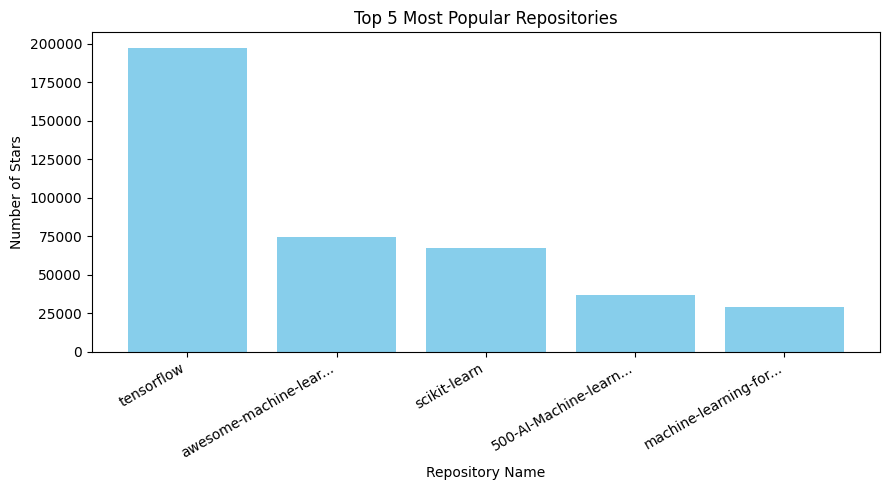

In [42]:
import matplotlib.pyplot as plt

query_top = "SELECT name, stars FROM Repositories ORDER BY stars DESC LIMIT 5;"
df_top = pd.read_sql_query(query_top, conn)

df_top['short_name'] = df_top['name'].apply(lambda x: x[:20] + '...' if len(x) > 20 else x)

plt.figure(figsize=(9, 5))
plt.bar(df_top['short_name'], df_top['stars'], color='skyblue')

plt.title('Top 5 Most Popular Repositories')
plt.xlabel('Repository Name')
plt.ylabel('Number of Stars')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

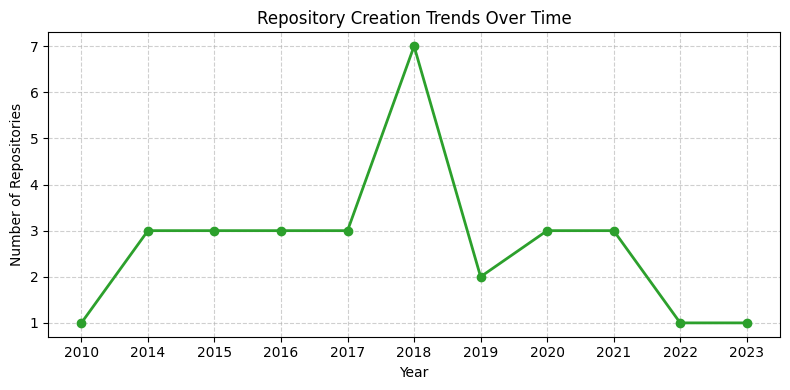

In [43]:
query_trend = "SELECT strftime('%Y', created_date) AS year, COUNT(*) AS count FROM Repositories WHERE year IS NOT NULL GROUP BY year ORDER BY year;"
df_trend = pd.read_sql_query(query_trend, conn)

plt.figure(figsize=(8, 4))
plt.plot(df_trend['year'], df_trend['count'], marker='o', color='#2ca02c', linewidth=2)

plt.title('Repository Creation Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Repositories')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ***Task 3***

In [44]:
!git init


Reinitialized existing Git repository in /content/.git/


In [45]:
!git status

On branch master
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   github_projects.csv
	modified:   github_projects.db

no changes added to commit (use "git add" and/or "git commit -a")


In [46]:
!git add .
!git commit -m "finish"

[master 6a6a88d] finish
 2 files changed, 3 insertions(+), 3 deletions(-)


# **Ethics Reflection**

**Question 1:** ***Why is it important to verify data collected from public APIs?***

To ensure the data is accurate, complete and preventing wrong analysis.

**Question 2:** ***Why should data analysts document the source of their data?***           
To keep transparency and alllow data analysts to work on it .

**Question 3:** ***How can missing or inaccurate data affect data analysis and decision-making?***  
It leads to wrong insights which  cause  incorrect conclusions and lost business opportunities.